## Banking Complaint Intake and Compliance-Routing Agent

### Use case

This notebook implements a banking complaint agent that validates customer input, classifies complaints, applies deterministic policy rules, routes cases to the appropriate department, creates or reuses tickets, and records an auditable execution trace.

The agent supports exactly six complaint categories: **account access, billing dispute, compliance violation, fraud, poor service, and service delay**.

### Architecture

The workflow uses a LangGraph `StateGraph` with deterministic and conditional routing.

The QLoRA fine-tuned `Qwen2.5-1.5B-Instruct` model from Assignment 1 performs complaint classification. Deterministic Python rules handle validation, policy lookup, completeness checks, duplicate detection, risk assessment, routing decisions, ticket creation, escalation, acknowledgements, and audit logging.

### Real and mocked components

The fine-tuned Qwen classifier is the real specialist component. It was evaluated on 250 unseen examples and achieved:

- **89.20% test accuracy**
- **89.10% Macro F1**

The customer database, previous-ticket database, ticket system, escalation queue, department notification system, and audit-log storage are mocked using in-memory Python structures.

Mocked tool activity is recorded in the execution trace with its input, output, timestamp, and mocked status.

### Agent decisions

The agent supports three main outcomes:

- `AUTO_RESOLVE`: create or reuse a ticket and continue normal processing.
- `REQUEST_MORE_INFO`: request information required for further processing.
- `ESCALATE`: route fraud, compliance, high-risk, invalid-output, low-confidence, overdue, or repeat-unresolved cases for human review.

Every result includes a `decision_source` showing which model output or deterministic rule produced the decision.

### Verified demonstrations

The notebook successfully demonstrates:

1. Classification and normal routing of an account-access complaint to Digital Banking Support.
2. Escalation of an urgent English–Roman Urdu fraud complaint to the Fraud Investigation Unit.
3. Deterministic validation and policy checks.
4. Ticket creation and duplicate-ticket handling.
5. Structured execution traces and mocked backend activity.
6. Rule-based detection of complaints containing multiple issues.

For multi-issue complaints, the issues are separated, but only the first detected issue is processed through the complete workflow.

### Compliance rules

The notebook uses a simplified and configurable demonstration policy table. It includes:

- A 48-hour acknowledgement target.
- A 10-working-day interim-response reference for cases requiring detailed scrutiny.
- A 30-day fraud final-response target.
- A separate 45-day external escalation-eligibility threshold.

These values are prototype rules and require legal and compliance validation before production use.

### Limitations

The displayed confidence value is an output-validity proxy, not a calibrated model probability.

The mocked databases reset when the notebook session restarts and do not represent integration with a real core-banking system.

The policy mappings are simplified for demonstration purposes. Customer acknowledgements are template-based to keep ticket identifiers, departments, and deadlines deterministic.

In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/datasets/batoolbintefazal/dataset-task-2/test.jsonl
/kaggle/input/datasets/batoolbintefazal/dataset-task-2/train.jsonl
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/__results__.html
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/__notebook__.ipynb
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/__output__.json
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/custom.css
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/qwen-banking-complaint-lora/README.md
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/qwen-banking-complaint-lora/checkpoint-38/adapter_model.safetensors
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/qwen-banking-complaint-lora/checkpoint-38/trainer_state.json


In [22]:
from pathlib import Path

adapter_configs = [
    path
    for path in Path("/kaggle/input").rglob("adapter_config.json")
    if path.parent.name == "qwen2.5-1.5b-banking-complaint-lora"
]

assert adapter_configs, "Final adapter was not found."

ADAPTER_DIR = str(adapter_configs[0].parent)

print("Notebook 2 will use:")
print(ADAPTER_DIR)

Notebook 2 will use:
/kaggle/input/notebooks/batoolbintefazal/complaint-triage-finetuning/qwen2.5-1.5b-banking-complaint-lora


Install required packages

In [24]:
!pip install -q peft bitsandbytes accelerate sentencepiece

Load the fine-tuned model

In [25]:
import json
import shutil
from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import PeftModel


BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# Copy the adapter because /kaggle/input is read-only
CLEAN_ADAPTER_DIR = Path(
    "/kaggle/working/qwen2.5-1.5b-banking-complaint-lora-clean"
)

if CLEAN_ADAPTER_DIR.exists():
    shutil.rmtree(CLEAN_ADAPTER_DIR)

shutil.copytree(
    ADAPTER_DIR,
    CLEAN_ADAPTER_DIR,
)

# Remove unsupported fields that caused the PEFT warning
config_path = CLEAN_ADAPTER_DIR / "adapter_config.json"

with config_path.open("r", encoding="utf-8") as file:
    adapter_config = json.load(file)

adapter_config.pop("monteclora_config", None)
adapter_config.pop("velora_config", None)

with config_path.open("w", encoding="utf-8") as file:
    json.dump(adapter_config, file, indent=2)

CLEAN_ADAPTER_DIR = str(CLEAN_ADAPTER_DIR)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(
    CLEAN_ADAPTER_DIR,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.float16,
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(
    base_model,
    CLEAN_ADAPTER_DIR,
)

model.eval()
model.config.use_cache = True

print("Final fine-tuned model loaded successfully!")
print("Clean adapter:", CLEAN_ADAPTER_DIR)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Final fine-tuned model loaded successfully!
Clean adapter: /kaggle/working/qwen2.5-1.5b-banking-complaint-lora-clean


Loads test.jsonl into test_df

In [26]:
from pathlib import Path
import pandas as pd

test_files = list(Path("/kaggle/input").rglob("test.jsonl"))

print("Test files found:")
for file in test_files:
    print(file)

assert test_files, "test.jsonl was not found."

matching_files = [
    file
    for file in test_files
    if "dataset-task-2" in str(file).lower()
]

TEST_FILE = matching_files[0] if matching_files else test_files[0]

test_df = pd.read_json(TEST_FILE, lines=True)

assert "messages" in test_df.columns, (
    f"'messages' column is missing. Found: {test_df.columns.tolist()}"
)

print("\nLoaded file:", TEST_FILE)
print("Test examples:", len(test_df))
print("Columns:", test_df.columns.tolist())

Test files found:
/kaggle/input/datasets/batoolbintefazal/dataset-task-2/test.jsonl

Loaded file: /kaggle/input/datasets/batoolbintefazal/dataset-task-2/test.jsonl
Test examples: 250
Columns: ['messages']


Evaluates the model using test_df

In [27]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

model.eval()
model.config.use_cache = True

# Remove irrelevant sampling settings from the saved generation configuration
model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

true_labels = []
predicted_labels = []

for row in tqdm(test_df["messages"], desc="Testing model"):

    true_label = next(
        message["content"].strip()
        for message in row
        if message["role"] == "assistant"
    )

    input_messages = [
        message
        for message in row
        if message["role"] != "assistant"
    ]

    prompt = tokenizer.apply_chat_template(
        input_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_tokens = output[
        0, inputs["input_ids"].shape[1]:
    ]

    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    true_labels.append(true_label)
    predicted_labels.append(prediction)

# Calculate metrics only after all 250 examples are processed
accuracy = accuracy_score(true_labels, predicted_labels)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0,
)

print("\nTest examples:", len(true_labels))
print(f"Test accuracy: {accuracy:.4f}")
print(f"Macro F1:     {macro_f1:.4f}")

Testing model:   0%|          | 0/250 [00:00<?, ?it/s]


Test examples: 250
Test accuracy: 0.8920
Macro F1:     0.8910


**Install LangGraph**

In [28]:
!pip install -q langgraph

**Define categories and compliance policy**

In [30]:
from datetime import datetime, timedelta, timezone
from typing import Any, Dict, List, Optional, TypedDict

COMPLAINT_CATEGORIES = [
    "account access",
    "billing dispute",
    "compliance violation",
    "fraud",
    "poor service",
    "service delay",
]

assert len(COMPLAINT_CATEGORIES) == 6
assert len(set(COMPLAINT_CATEGORIES)) == 6

POLICY_TABLE = {
    "account access": {
        "department": "Digital Banking Support",
        "resolution_sla_days": 15,
        "risk_tier": "medium",
    },
    "billing dispute": {
        "department": "Billing and Disputes Unit",
        "resolution_sla_days": 30,
        "risk_tier": "medium",
    },
    "compliance violation": {
        "department": "Compliance Department",
        "resolution_sla_days": 15,
        "risk_tier": "high",
    },
    "fraud": {
        "department": "Fraud Investigation Unit",
        "resolution_sla_days": 30,
        "risk_tier": "high",
    },
    "poor service": {
        "department": "Customer Experience Unit",
        "resolution_sla_days": 15,
        "risk_tier": "low",
    },
    "service delay": {
        "department": "Banking Operations Unit",
        "resolution_sla_days": 15,
        "risk_tier": "medium",
    },
}

DEFAULT_POLICY = {
    "department": "Complaint Management Unit",
    "resolution_sla_days": 30,
    "risk_tier": "medium",
}

ACKNOWLEDGEMENT_SLA_HOURS = 48
INTERIM_RESPONSE_WORKING_DAYS = 10
FRAUD_FINAL_RESPONSE_DAYS = 30
EXTERNAL_ESCALATION_ELIGIBILITY_DAYS = 45

# This is a proxy-confidence threshold, not a calibrated probability.
CONFIDENCE_ESCALATION_THRESHOLD = 0.55

assert set(POLICY_TABLE) == set(COMPLAINT_CATEGORIES)

print("Configuration validated successfully.")
print("Complaint categories:", COMPLAINT_CATEGORIES)

Configuration validated successfully.
Complaint categories: ['account access', 'billing dispute', 'compliance violation', 'fraud', 'poor service', 'service delay']


**Define the LangGraph state**

In [31]:
# This cell defines the shared state that carries complaint data and tool results through LangGraph.

class ComplaintState(TypedDict, total=False):
    # Original input
    customer_id: str
    complaint_text: str
    channel: str
    received_at: str

    # Text processing
    normalized_text: str
    sub_complaints: List[str]
    multi_issue_detected: bool

    # Fine-tuned model output
    raw_model_output: str
    predicted_category: Optional[str]
    confidence: float
    classification_valid: bool

    # Mocked tool results
    customer_history: Dict[str, Any]
    is_duplicate: bool
    duplicate_ticket_id: Optional[str]
    duplicate_opened_days_ago: Optional[int]
    policy: Dict[str, Any]
    sla: Dict[str, Any]
    missing_fields: List[str]
    assigned_department: Optional[str]

    # Final action
    decision: Optional[str]
    decision_source: Optional[str]
    ticket_id: Optional[str]
    response: Optional[str]
    escalation_reason: Optional[str]

    # Audit trail
    trace: List[Dict[str, Any]]


VALID_DECISIONS = {
    "AUTO_RESOLVE",
    "REQUEST_MORE_INFO",
    "ESCALATE",
}

print("ComplaintState schema created.")

ComplaintState schema created.


**Create mocked banking systems**

In [32]:
MOCK_CUSTOMER_DB: Dict[str, Dict[str, Any]] = {
    "CUST-1001": {
        "name": "Ayesha Khan",
        "account_age_years": 4,
        "prior_complaints_90d": 0,
        "prior_unresolved": 0,
    },
    "CUST-1002": {
        "name": "Hamza Ali",
        "account_age_years": 2,
        "prior_complaints_90d": 1,
        "prior_unresolved": 0,
    },
    "CUST-1003": {
        "name": "Sara Ahmed",
        "account_age_years": 6,
        "prior_complaints_90d": 2,
        "prior_unresolved": 1,
    },
    "CUST-1004": {
        "name": "Bilal Hassan",
        "account_age_years": 3,
        "prior_complaints_90d": 1,
        "prior_unresolved": 0,
    },
}

INITIAL_OPEN_TICKETS: Dict[str, Dict[str, Any]] = {
    "CUST-1004": {
        "ticket_id": "TCK-0099",
        "category": "service delay",
        "opened_days_ago": 4,
        "status": "IN_PROGRESS",
    }
}

MOCK_OPEN_TICKETS: Dict[str, Dict[str, Any]] = {}
MOCK_ESCALATION_QUEUE: List[Dict[str, Any]] = []
MOCK_AUDIT_LOG: List[Dict[str, Any]] = []

_ticket_counter = {"n": 1000}


def reset_mock_systems() -> None:
    """Reset mocked systems so repeated notebook runs remain reproducible."""
    global MOCK_OPEN_TICKETS
    global MOCK_ESCALATION_QUEUE
    global MOCK_AUDIT_LOG

    MOCK_OPEN_TICKETS = {
        customer_id: ticket.copy()
        for customer_id, ticket in INITIAL_OPEN_TICKETS.items()
    }
    MOCK_ESCALATION_QUEUE = []
    MOCK_AUDIT_LOG = []
    _ticket_counter["n"] = 1000


def next_ticket_id() -> str:
    """Create a new mock complaint-ticket identifier."""
    _ticket_counter["n"] += 1
    return f"TCK-{_ticket_counter['n']:04d}"


reset_mock_systems()

print("Mock customer records:", len(MOCK_CUSTOMER_DB))
print("Initially open tickets:", len(MOCK_OPEN_TICKETS))

Mock customer records: 4
Initially open tickets: 1


**Add audit and text helpers**

In [33]:
import re


def utc_timestamp() -> str:
    """Return a timezone-aware timestamp for the audit trail."""
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def add_trace(
    state: ComplaintState,
    node: str,
    summary: str,
    *,
    tool_name: Optional[str] = None,
    tool_input: Any = None,
    tool_output: Any = None,
    mocked: bool = False,
) -> ComplaintState:
    """Return a new state containing one additional structured audit entry."""
    entry = {
        "timestamp": utc_timestamp(),
        "node": node,
        "summary": summary,
        "tool_name": tool_name,
        "tool_input": tool_input,
        "tool_output": tool_output,
        "mocked": mocked,
    }

    return {
        **state,
        "trace": list(state.get("trace", [])) + [entry],
    }


def normalize_text(text: str) -> str:
    """Normalize whitespace and common banking abbreviations."""
    text = text.strip().lower()

    replacements = {
        r"\btxn\b": "transaction",
        r"\bacct\b": "account",
        r"\bacc\b": "account",
        r"\bamt\b": "amount",
        r"\bref no\b": "reference number",
        r"\bpkr\.\b": "pkr",
    }

    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text)

    return re.sub(r"\s+", " ", text).strip()


def canonicalize_model_label(raw_output: str):
    """
    Validate the generated label against the exact six-category label set.

    Confidence is a transparent output-validity proxy:
    0.95 = exact valid label
    0.85 = valid label after punctuation/format cleanup
    0.65 = one unambiguous category found inside extra text
    0.00 = invalid or ambiguous output
    """
    raw = raw_output.strip().lower()
    first_line = raw.splitlines()[0].strip() if raw else ""

    if first_line in COMPLAINT_CATEGORIES:
        return first_line, 0.95, True

    cleaned = re.sub(r"^[\s\"'`*#:\-]+|[\s\"'`*#.,:;\-]+$", "", first_line)

    if cleaned in COMPLAINT_CATEGORIES:
        return cleaned, 0.85, True

    matches = [
        category
        for category in COMPLAINT_CATEGORIES
        if category in raw
    ]

    if len(matches) == 1:
        return matches[0], 0.65, True

    return None, 0.0, False


print("Helper functions created.")

Helper functions created.


**Classification function**

In [34]:
def classify_with_finetuned_qwen(text: str) -> Dict[str, Any]:
    """Classify one complaint using the loaded Qwen LoRA model."""

    classification_messages = [
        {
            "role": "system",
            "content": (
                "Classify the banking complaint into exactly one category. "
                "Return only the category label and nothing else.\n"
                "Valid categories: account access, billing dispute, "
                "compliance violation, fraud, poor service, service delay."
            ),
        },
        {
            "role": "user",
            "content": text,
        },
    ]

    prompt = tokenizer.apply_chat_template(
        classification_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(model.device)

    # Remove irrelevant sampling values from the saved generation configuration.
    model.generation_config.do_sample = False
    model.generation_config.temperature = None
    model.generation_config.top_p = None
    model.generation_config.top_k = None

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_tokens = output[
        0, inputs["input_ids"].shape[1]:
    ]

    raw_output = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    category, confidence, valid = canonicalize_model_label(raw_output)

    return {
        "raw_model_output": raw_output,
        "predicted_category": category,
        "confidence": confidence,
        "classification_valid": valid,
    }


print("Fine-tuned Qwen classifier is ready.")

Fine-tuned Qwen classifier is ready.


**Define Nodes**

In [36]:
# First agent nodes:
# validation, normalization, multi-issue detection,
# robust Qwen classification, and confidence gate.

import re


def node_intake_and_validate(
    state: ComplaintState,
) -> ComplaintState:
    customer_id = str(
        state.get("customer_id", "")
    ).strip()

    complaint_text = str(
        state.get("complaint_text", "")
    ).strip()

    missing = []

    if not customer_id:
        missing.append("customer ID")

    if len(complaint_text) < 6:
        missing.append("a usable complaint description")

    updates: ComplaintState = {
        **state,
        "customer_id": customer_id,
        "complaint_text": complaint_text,
        "missing_fields": missing,
    }

    if missing:
        updates["decision"] = "REQUEST_MORE_INFO"
        updates["decision_source"] = "input_validation"

        return add_trace(
            updates,
            "intake_and_validate",
            (
                "Input validation failed; additional "
                "information is required."
            ),
            tool_name="validate_intake",
            tool_input={
                "customer_id": customer_id,
                "complaint_text": complaint_text,
            },
            tool_output={
                "missing_fields": missing,
            },
            mocked=False,
        )

    return add_trace(
        updates,
        "intake_and_validate",
        "Customer ID and complaint text passed validation.",
        tool_name="validate_intake",
        tool_input={
            "customer_id": customer_id,
            "complaint_length": len(complaint_text),
        },
        tool_output={
            "valid": True,
        },
        mocked=False,
    )


def node_normalize_complaint(
    state: ComplaintState,
) -> ComplaintState:
    normalized = normalize_text(
        state.get("complaint_text", "")
    )

    updated = {
        **state,
        "normalized_text": normalized,
    }

    return add_trace(
        updated,
        "normalize_complaint",
        "Complaint text was normalized.",
        tool_name="normalize_text",
        tool_input=state.get("complaint_text", ""),
        tool_output=normalized,
        mocked=False,
    )


def node_split_multi_issue(
    state: ComplaintState,
) -> ComplaintState:
    text = (
        state.get("normalized_text")
        or state.get("complaint_text")
        or ""
    )

    split_pattern = (
        r"\s+(?:and also|also|aur saath|aur bhi)\s+"
        r"|;\s*"
        r"|\.\s+(?=also\b)"
        r"|\s+\d+[\)\.]\s+"
    )

    parts = [
        part.strip(" .")
        for part in re.split(
            split_pattern,
            text,
            flags=re.IGNORECASE,
        )
        if part.strip(" .")
    ]

    if not parts:
        parts = [text]

    multi_issue = len(parts) > 1

    updated = {
        **state,
        "sub_complaints": parts,
        "multi_issue_detected": multi_issue,
    }

    if multi_issue:
        summary = (
            f"Detected {len(parts)} complaint issues; "
            "the first issue will be processed through "
            "the main prototype workflow."
        )
    else:
        summary = "A single complaint issue was detected."

    return add_trace(
        updated,
        "split_multi_issue",
        summary,
        tool_name="split_multi_issue",
        tool_input=text,
        tool_output={
            "sub_complaints": parts,
            "multi_issue_detected": multi_issue,
        },
        mocked=False,
    )


def normalize_category_format(value):
    """
    Normalize a category only for comparison.

    These all become the same comparison value:
        account_access
        account-access
        Account Access
        category: account_access
    """
    if value is None:
        return ""

    cleaned = str(value).lower().strip()

    cleaned = cleaned.strip(
        " \n\t.,:;!?\"'`()[]{}"
    )

    cleaned = re.sub(
        r"^(the\s+)?"
        r"(predicted\s+)?"
        r"(category|label|classification|answer)"
        r"\s*(is|=|:|-)?\s*",
        "",
        cleaned,
    )

    cleaned = cleaned.strip(
        " \n\t.,:;!?\"'`()[]{}"
    )

    cleaned = re.sub(r"[_-]+", " ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned)

    return cleaned.strip()


def parse_model_category(raw_output):
    """
    Convert the Qwen output into the exact category format
    already used by COMPLAINT_CATEGORIES.

    For example, if COMPLAINT_CATEGORIES contains
    'account access', then 'account_access' becomes
    'account access'.

    If COMPLAINT_CATEGORIES contains 'account_access',
    that exact configured value is returned instead.
    """
    if raw_output is None:
        return None

    normalized_output = normalize_category_format(
        raw_output
    )

    if not normalized_output:
        return None

    # Return the exact configured category value.
    for category in COMPLAINT_CATEGORIES:
        if (
            normalize_category_format(category)
            == normalized_output
        ):
            return category

    # Allow one category inside a short explanatory answer.
    detected_categories = []

    for category in COMPLAINT_CATEGORIES:
        normalized_category = normalize_category_format(
            category
        )

        pattern = (
            r"(?<![a-z0-9])"
            + re.escape(normalized_category)
            + r"(?![a-z0-9])"
        )

        if re.search(pattern, normalized_output):
            detected_categories.append(category)

    detected_categories = list(
        dict.fromkeys(detected_categories)
    )

    if len(detected_categories) == 1:
        return detected_categories[0]

    return None


def node_classify_complaint(
    state: ComplaintState,
) -> ComplaintState:
    sub_complaints = (
        state.get("sub_complaints")
        or []
    )

    if sub_complaints:
        classification_text = sub_complaints[0]
    else:
        classification_text = (
            state.get("normalized_text")
            or state.get("complaint_text")
            or ""
        )

    # Keep using your existing Assignment 1
    # fine-tuned Qwen classification function.
    result = classify_with_finetuned_qwen(
        classification_text
    )

    if not isinstance(result, dict):
        result = {
            "raw_model_output": str(result),
        }

    raw_output = (
        result.get("raw_model_output")
        or result.get("model_output")
        or result.get("generated_text")
        or result.get("predicted_category")
    )

    predicted_category = parse_model_category(
        raw_output
    )

    classification_valid = (
        predicted_category in COMPLAINT_CATEGORIES
    )

    # Output-validity proxy, not a calibrated probability.
    confidence = (
        1.0
        if classification_valid
        else 0.0
    )

    updated = {
        **state,
        **result,
        "raw_model_output": (
            str(raw_output)
            if raw_output is not None
            else ""
        ),
        "predicted_category": predicted_category,
        "classification_valid": classification_valid,
        "confidence": confidence,
    }

    if classification_valid:
        summary = (
            "The Assignment 1 fine-tuned Qwen model "
            f"classified the complaint as "
            f"'{predicted_category}'."
        )
    else:
        summary = (
            "The Qwen output could not be converted "
            "into exactly one configured complaint category."
        )

    return add_trace(
        updated,
        "classify_complaint",
        summary,
        tool_name="fine_tuned_qwen_classifier",
        tool_input=classification_text,
        tool_output={
            "raw_model_output": (
                str(raw_output)
                if raw_output is not None
                else ""
            ),
            "predicted_category": predicted_category,
            "classification_valid": classification_valid,
            "confidence_proxy": confidence,
        },
        mocked=False,
    )


def node_confidence_gate(
    state: ComplaintState,
) -> ComplaintState:
    valid = bool(
        state.get("classification_valid", False)
    )

    confidence = float(
        state.get("confidence", 0.0)
    )

    updated = dict(state)

    if not valid:
        updated["decision"] = "ESCALATE"
        updated["decision_source"] = "confidence_gate"
        updated["escalation_reason"] = (
            "The model output did not match exactly one "
            "configured complaint category."
        )

        summary = (
            "Invalid classification output was routed "
            "to human review."
        )

    elif confidence < CONFIDENCE_ESCALATION_THRESHOLD:
        updated["decision"] = "ESCALATE"
        updated["decision_source"] = "confidence_gate"
        updated["escalation_reason"] = (
            "Classification proxy confidence was below "
            "the safety threshold."
        )

        summary = (
            "Low-confidence classification was routed "
            "to human review."
        )

    else:
        # Clear any obsolete classification escalation values.
        if (
            updated.get("decision_source")
            == "confidence_gate"
        ):
            updated["decision"] = None
            updated["decision_source"] = None
            updated["escalation_reason"] = None

        summary = (
            "Classification passed the output-validity "
            "confidence gate."
        )

    return add_trace(
        updated,
        "confidence_gate",
        summary,
        tool_name="classification_safety_gate",
        tool_input={
            "raw_model_output": state.get(
                "raw_model_output"
            ),
            "category": state.get(
                "predicted_category"
            ),
            "confidence": confidence,
            "valid": valid,
        },
        tool_output={
            "decision": updated.get("decision"),
            "passed": (
                updated.get("decision") != "ESCALATE"
            ),
        },
        mocked=False,
    )

**Mocked lookup and policy tools**

In [38]:
def node_duplicate_check(state: ComplaintState) -> ComplaintState:
    existing = MOCK_OPEN_TICKETS.get(state["customer_id"])
    category = state.get("predicted_category")

    is_duplicate = bool(
        existing
        and existing.get("category") == category
        and existing.get("status") in {"OPEN", "IN_PROGRESS"}
    )

    updated = {
        **state,
        "is_duplicate": is_duplicate,
        "duplicate_ticket_id": (
            existing.get("ticket_id") if is_duplicate else None
        ),
        "duplicate_opened_days_ago": (
            existing.get("opened_days_ago") if is_duplicate else None
        ),
    }

    return add_trace(
        updated,
        "duplicate_check",
        (
            f"Possible duplicate matched ticket {existing['ticket_id']}."
            if is_duplicate
            else "No matching open complaint was found."
        ),
        tool_name="find_possible_duplicate",
        tool_input={
            "customer_id": state["customer_id"],
            "category": category,
        },
        tool_output={
            "is_duplicate": is_duplicate,
            "existing_ticket": existing if is_duplicate else None,
        },
        mocked=True,
    )


def node_customer_history_lookup(state: ComplaintState) -> ComplaintState:
    default_history = {
        "name": "Unknown Customer",
        "account_age_years": None,
        "prior_complaints_90d": 0,
        "prior_unresolved": 0,
    }

    history = MOCK_CUSTOMER_DB.get(
        state["customer_id"],
        default_history,
    ).copy()

    updated = {
        **state,
        "customer_history": history,
    }

    return add_trace(
        updated,
        "customer_history_lookup",
        "Mock customer complaint history was retrieved.",
        tool_name="lookup_customer_history",
        tool_input={"customer_id": state["customer_id"]},
        tool_output=history,
        mocked=True,
    )


def node_policy_lookup(state: ComplaintState) -> ComplaintState:
    category = state.get("predicted_category")
    policy = POLICY_TABLE.get(category, DEFAULT_POLICY).copy()

    updated = {
        **state,
        "policy": policy,
        "assigned_department": policy["department"],
    }

    return add_trace(
        updated,
        "policy_lookup",
        "The configured policy for the predicted category was retrieved.",
        tool_name="lookup_policy",
        tool_input={"category": category},
        tool_output=policy,
        mocked=True,
    )


def calculate_deadlines(
    received_at: str,
    category: str,
    policy: Dict[str, Any],
) -> Dict[str, Any]:
    received = datetime.fromisoformat(
        received_at.replace("Z", "+00:00")
    )

    resolution_days = (
        FRAUD_FINAL_RESPONSE_DAYS
        if category == "fraud"
        else int(policy["resolution_sla_days"])
    )

    return {
        "acknowledgement_deadline_hours": ACKNOWLEDGEMENT_SLA_HOURS,
        "acknowledgement_due_at": (
            received + timedelta(hours=ACKNOWLEDGEMENT_SLA_HOURS)
        ).isoformat(),
        "interim_response_after_working_days": (
            INTERIM_RESPONSE_WORKING_DAYS
        ),
        "resolution_deadline_days": resolution_days,
        "resolution_due_at": (
            received + timedelta(days=resolution_days)
        ).isoformat(),
        "external_escalation_eligibility_days": (
            EXTERNAL_ESCALATION_ELIGIBILITY_DAYS
        ),
    }


def node_sla_calculator(state: ComplaintState) -> ComplaintState:
    sla = calculate_deadlines(
        received_at=state["received_at"],
        category=state["predicted_category"],
        policy=state["policy"],
    )

    updated = {
        **state,
        "sla": sla,
    }

    return add_trace(
        updated,
        "sla_calculator",
        "Acknowledgement and resolution deadlines were calculated deterministically.",
        tool_name="calculate_deadlines",
        tool_input={
            "received_at": state["received_at"],
            "category": state["predicted_category"],
            "policy": state["policy"],
        },
        tool_output=sla,
        mocked=False,
    )

**Completeness, risk, routing, and decision nodes**

In [40]:
def detect_required_information(
    text: str,
    category: str,
) -> List[str]:
    missing: List[str] = []

    amount_present = bool(
        re.search(
            r"\b(?:pkr|rs\.?|rupees?)\s*[\d,]+"
            r"|[\d,]+\s*(?:pkr|rupees?)\b",
            text,
            flags=re.IGNORECASE,
        )
    )

    date_present = bool(
        re.search(
            r"\b\d{1,2}[/-]\d{1,2}(?:[/-]\d{2,4})?\b"
            r"|\b(?:today|yesterday|kal|aaj)\b"
            r"|\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)"
            r"[a-z]*\s+\d{1,2}\b"
            r"|\b\d{1,2}\s+(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)"
            r"[a-z]*\b",
            text,
            flags=re.IGNORECASE,
        )
    )

    reference_present = bool(
        re.search(
            r"\b(?:reference|ref|transaction id|transaction number|"
            r"merchant|atm|card ending|invoice)\b",
            text,
            flags=re.IGNORECASE,
        )
    )

    if category in {"fraud", "billing dispute"}:
        if not amount_present:
            missing.append("transaction amount")
        if not date_present:
            missing.append("transaction date")
        if not reference_present:
            missing.append("merchant or transaction reference")

    elif category == "service delay":
        if not date_present:
            missing.append("service or transaction date")
        if not reference_present:
            missing.append("transaction or service reference")

    elif category == "poor service":
        branch_or_channel_present = bool(
            re.search(
                r"\b(?:branch|app|call center|helpline|website|counter)\b",
                text,
                flags=re.IGNORECASE,
            )
        )
        if not branch_or_channel_present:
            missing.append("service channel or branch")

    elif category == "compliance violation":
        if not date_present:
            missing.append("incident date")

    return missing


def node_completeness_check(state: ComplaintState) -> ComplaintState:
    missing = detect_required_information(
        state["normalized_text"],
        state["predicted_category"],
    )

    updated = {
        **state,
        "missing_fields": missing,
    }

    return add_trace(
        updated,
        "completeness_check",
        (
            "Critical complaint details are missing."
            if missing
            else "The complaint contains the required information."
        ),
        tool_name="check_required_information",
        tool_input={
            "category": state["predicted_category"],
            "text": state["normalized_text"],
        },
        tool_output={"missing_fields": missing},
        mocked=False,
    )


def node_risk_and_escalation_check(
    state: ComplaintState,
) -> ComplaintState:
    policy = state["policy"]
    history = state["customer_history"]
    sla = state["sla"]

    reasons = []

    if policy["risk_tier"] == "high":
        reasons.append(
            f"{state['predicted_category']} is configured as high risk"
        )

    if int(history.get("prior_unresolved", 0)) >= 1:
        reasons.append("customer has a prior unresolved complaint")

    if state.get("is_duplicate"):
        opened_days = int(
            state.get("duplicate_opened_days_ago") or 0
        )
        resolution_days = int(sla["resolution_deadline_days"])

        if opened_days > resolution_days:
            reasons.append("existing duplicate ticket is overdue")

    updated = dict(state)

    if reasons:
        updated["decision"] = "ESCALATE"
        updated["decision_source"] = "risk_rule"
        updated["escalation_reason"] = "; ".join(reasons)
        summary = "Risk rules required priority escalation."
    else:
        summary = "No mandatory escalation rule was triggered."

    return add_trace(
        updated,
        "risk_and_escalation_check",
        summary,
        tool_name="check_risk_and_escalation",
        tool_input={
            "risk_tier": policy["risk_tier"],
            "prior_unresolved": history.get("prior_unresolved", 0),
            "is_duplicate": state.get("is_duplicate", False),
        },
        tool_output={
            "escalate": bool(reasons),
            "reasons": reasons,
        },
        mocked=False,
    )


def node_department_router(state: ComplaintState) -> ComplaintState:
    department = state.get(
        "assigned_department",
        "Complaint Management Unit",
    )

    updated = {
        **state,
        "assigned_department": department,
    }

    return add_trace(
        updated,
        "department_router",
        f"The complaint was routed to {department}.",
        tool_name="lookup_department",
        tool_input={"category": state.get("predicted_category")},
        tool_output={"department": department},
        mocked=True,
    )


def node_decide_route(state: ComplaintState) -> ComplaintState:
    updated = dict(state)

    # Preserve any decision already made by validation, confidence, or risk.
    if state.get("decision"):
        summary = (
            f"The earlier {state.get('decision_source')} decision was preserved."
        )

    elif state.get("is_duplicate"):
        updated["decision"] = "AUTO_RESOLVE"
        updated["decision_source"] = "duplicate_rule"
        summary = "The customer was linked to an existing open ticket."

    elif state.get("missing_fields"):
        updated["decision"] = "REQUEST_MORE_INFO"
        updated["decision_source"] = "completeness_rule"
        summary = "Additional information is required before normal processing."

    else:
        updated["decision"] = "AUTO_RESOLVE"
        updated["decision_source"] = "policy_rule"
        summary = "A complete, non-high-risk complaint can enter normal processing."

    assert updated["decision"] in VALID_DECISIONS

    return add_trace(
        updated,
        "decide_route",
        summary,
        tool_name="apply_routing_rules",
        tool_input={
            "existing_decision": state.get("decision"),
            "is_duplicate": state.get("is_duplicate", False),
            "missing_fields": state.get("missing_fields", []),
        },
        tool_output={
            "decision": updated["decision"],
            "decision_source": updated["decision_source"],
        },
        mocked=False,
    )

**Define ticket, acknowledgement, escalation, and audit tools**

In [42]:
def node_create_ticket(
    state: ComplaintState,
) -> ComplaintState:
    if (
        state.get("is_duplicate")
        and state.get("duplicate_ticket_id")
    ):
        ticket_id = state["duplicate_ticket_id"]
        created_new = False

    else:
        ticket_id = next_ticket_id()
        created_new = True

        MOCK_OPEN_TICKETS[
            state.get("customer_id", "UNKNOWN")
        ] = {
            "ticket_id": ticket_id,
            "category": (
                state.get("predicted_category")
                or "unclassified"
            ),
            "opened_days_ago": 0,
            "status": "OPEN",
            "decision": state.get("decision"),
        }

    updated = {
        **state,
        "ticket_id": ticket_id,
    }

    return add_trace(
        updated,
        "create_ticket",
        (
            f"Created new mocked ticket {ticket_id}."
            if created_new
            else f"Reused existing mocked ticket {ticket_id}."
        ),
        tool_name="create_complaint_ticket",
        tool_input={
            "customer_id": state.get("customer_id"),
            "category": state.get("predicted_category"),
            "decision": state.get("decision"),
        },
        tool_output={
            "ticket_id": ticket_id,
            "created_new": created_new,
        },
        mocked=True,
    )


def node_generate_acknowledgement(
    state: ComplaintState,
) -> ComplaintState:
    decision = state.get("decision") or "ESCALATE"
    ticket_id = state.get("ticket_id") or "PENDING"

    # The `or` fallback also works when the stored value is None.
    department = (
        state.get("assigned_department")
        or "Complaint Management Unit"
    )

    sla = state.get("sla") or {}

    acknowledgement_hours = sla.get(
        "acknowledgement_deadline_hours",
        ACKNOWLEDGEMENT_SLA_HOURS,
    )

    if decision == "REQUEST_MORE_INFO":
        missing = (
            state.get("missing_fields")
            or ["additional complaint details"]
        )

        response = (
            f"Your request has been recorded under Ticket {ticket_id}. "
            f"Please provide: {', '.join(missing)}. "
            "Processing will continue after the required information "
            "is received."
        )

    elif decision == "ESCALATE":
        reason = (
            state.get("escalation_reason")
            or "human review is required"
        )

        response = (
            f"Your complaint has been recorded under Ticket {ticket_id} "
            f"and escalated to {department} for priority review. "
            f"Reason: {reason}. "
            f"An acknowledgement will be issued within "
            f"{acknowledgement_hours} hours."
        )

    elif (
        state.get("is_duplicate")
        and state.get("duplicate_ticket_id")
    ):
        response = (
            f"This complaint matches existing Ticket {ticket_id}. "
            "It has been linked to the open case instead of creating "
            "a duplicate complaint."
        )

    else:
        resolution_days = sla.get(
            "resolution_deadline_days",
            "the applicable",
        )

        response = (
            f"Your complaint has been registered as Ticket {ticket_id} "
            f"and assigned to {department}. "
            f"An acknowledgement will be issued within "
            f"{acknowledgement_hours} hours. "
            f"The configured prototype resolution timeline is "
            f"{resolution_days} days."
        )

    updated = {
        **state,
        "assigned_department": department,
        "response": response,
    }

    return add_trace(
        updated,
        "generate_acknowledgement",
        "A deterministic customer acknowledgement was generated.",
        tool_name="generate_acknowledgement",
        tool_input={
            "decision": decision,
            "ticket_id": ticket_id,
            "department": department,
        },
        tool_output={
            "response": response,
        },
        mocked=True,
    )


def node_escalate_case(
    state: ComplaintState,
) -> ComplaintState:
    category = state.get("predicted_category")

    escalation_target = (
        "Fraud Investigation Unit"
        if category == "fraud"
        else "Compliance and Human Review Queue"
    )

    record = {
        "ticket_id": state.get("ticket_id"),
        "customer_id": state.get("customer_id"),
        "category": category,
        "target": escalation_target,
        "reason": (
            state.get("escalation_reason")
            or "Human review is required."
        ),
        "timestamp": utc_timestamp(),
    }

    MOCK_ESCALATION_QUEUE.append(record)

    updated = {
        **state,
        "assigned_department": (
            state.get("assigned_department")
            or escalation_target
        ),
    }

    return add_trace(
        updated,
        "escalate_case",
        f"The ticket was added to {escalation_target}.",
        tool_name="notify_compliance",
        tool_input={
            "ticket_id": state.get("ticket_id"),
            "reason": record["reason"],
        },
        tool_output=record,
        mocked=True,
    )


def node_finalize_audit(
    state: ComplaintState,
) -> ComplaintState:
    record = {
        "ticket_id": state.get("ticket_id"),
        "customer_id": state.get("customer_id"),
        "category": state.get("predicted_category"),
        "decision": state.get("decision"),
        "decision_source": state.get("decision_source"),
        "department": (
            state.get("assigned_department")
            or "Complaint Management Unit"
        ),
        "trace": list(state.get("trace") or []),
        "saved_at": utc_timestamp(),
    }

    MOCK_AUDIT_LOG.append(record)

    return add_trace(
        state,
        "finalize_audit",
        "The complete mocked audit record was saved.",
        tool_name="save_audit_log",
        tool_input={
            "ticket_id": state.get("ticket_id"),
            "decision": state.get("decision"),
        },
        tool_output={
            "audit_records_saved": len(MOCK_AUDIT_LOG),
        },
        mocked=True,
    )

**LangGraph agent**

In [43]:
# connect all nodes 
from langgraph.graph import END, StateGraph


def route_after_intake(state: ComplaintState) -> str:
    return (
        "invalid_input"
        if state.get("decision") == "REQUEST_MORE_INFO"
        else "continue"
    )


def route_after_confidence_gate(state: ComplaintState) -> str:
    return (
        "human_review"
        if state.get("decision") == "ESCALATE"
        else "continue"
    )


def route_after_acknowledgement(state: ComplaintState) -> str:
    return (
        "escalate"
        if state.get("decision") == "ESCALATE"
        else "finish"
    )


workflow = StateGraph(ComplaintState)

workflow.add_node(
    "intake_and_validate",
    node_intake_and_validate,
)
workflow.add_node(
    "normalize_complaint",
    node_normalize_complaint,
)
workflow.add_node(
    "split_multi_issue",
    node_split_multi_issue,
)
workflow.add_node(
    "classify_complaint",
    node_classify_complaint,
)
workflow.add_node(
    "confidence_gate",
    node_confidence_gate,
)
workflow.add_node(
    "duplicate_check",
    node_duplicate_check,
)
workflow.add_node(
    "customer_history_lookup",
    node_customer_history_lookup,
)
workflow.add_node(
    "policy_lookup",
    node_policy_lookup,
)
workflow.add_node(
    "sla_calculator",
    node_sla_calculator,
)
workflow.add_node(
    "completeness_check",
    node_completeness_check,
)
workflow.add_node(
    "risk_and_escalation_check",
    node_risk_and_escalation_check,
)
workflow.add_node(
    "department_router",
    node_department_router,
)
workflow.add_node(
    "decide_route",
    node_decide_route,
)
workflow.add_node(
    "create_ticket",
    node_create_ticket,
)
workflow.add_node(
    "generate_acknowledgement",
    node_generate_acknowledgement,
)
workflow.add_node(
    "escalate_case",
    node_escalate_case,
)
workflow.add_node(
    "finalize_audit",
    node_finalize_audit,
)

workflow.set_entry_point("intake_and_validate")

workflow.add_conditional_edges(
    "intake_and_validate",
    route_after_intake,
    {
        "invalid_input": "create_ticket",
        "continue": "normalize_complaint",
    },
)

workflow.add_edge(
    "normalize_complaint",
    "split_multi_issue",
)
workflow.add_edge(
    "split_multi_issue",
    "classify_complaint",
)
workflow.add_edge(
    "classify_complaint",
    "confidence_gate",
)

workflow.add_conditional_edges(
    "confidence_gate",
    route_after_confidence_gate,
    {
        "human_review": "create_ticket",
        "continue": "duplicate_check",
    },
)

workflow.add_edge(
    "duplicate_check",
    "customer_history_lookup",
)
workflow.add_edge(
    "customer_history_lookup",
    "policy_lookup",
)
workflow.add_edge(
    "policy_lookup",
    "sla_calculator",
)
workflow.add_edge(
    "sla_calculator",
    "completeness_check",
)
workflow.add_edge(
    "completeness_check",
    "risk_and_escalation_check",
)
workflow.add_edge(
    "risk_and_escalation_check",
    "department_router",
)
workflow.add_edge(
    "department_router",
    "decide_route",
)
workflow.add_edge(
    "decide_route",
    "create_ticket",
)
workflow.add_edge(
    "create_ticket",
    "generate_acknowledgement",
)

workflow.add_conditional_edges(
    "generate_acknowledgement",
    route_after_acknowledgement,
    {
        "escalate": "escalate_case",
        "finish": "finalize_audit",
    },
)

workflow.add_edge(
    "escalate_case",
    "finalize_audit",
)
workflow.add_edge(
    "finalize_audit",
    END,
)

complaint_agent = workflow.compile()

print("LangGraph complaint agent compiled successfully!")

LangGraph complaint agent compiled successfully!


**Agent Architecture**

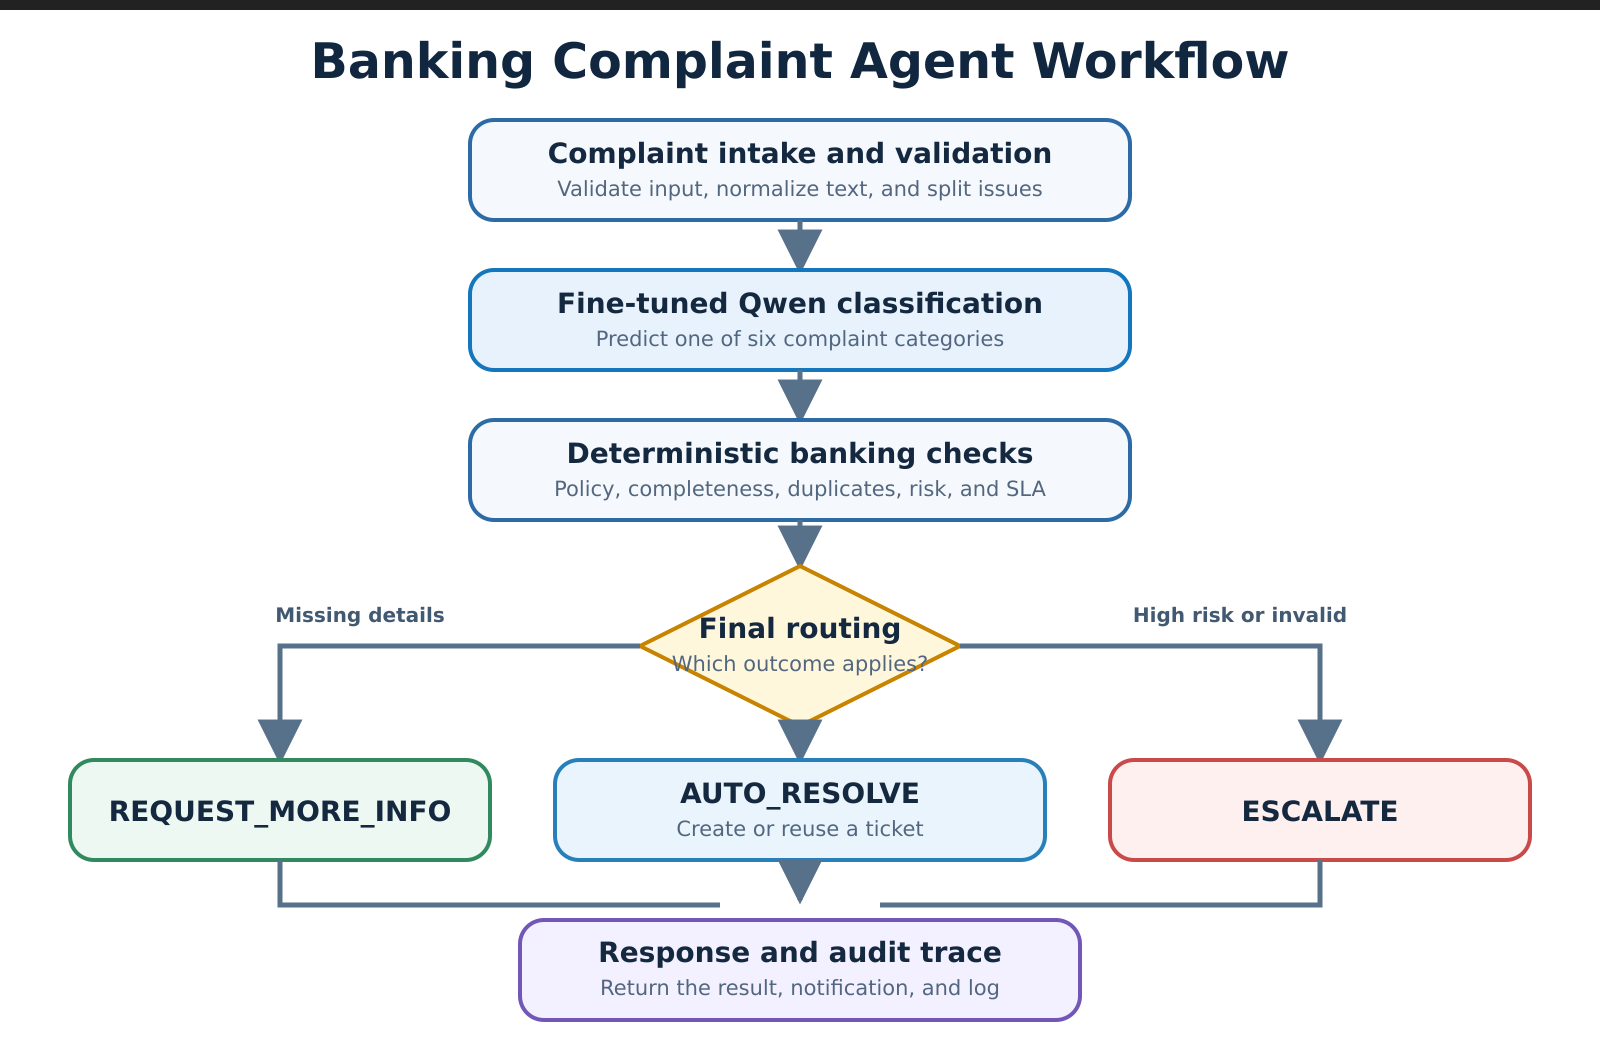

In [92]:
import glob
from IPython.display import Image, display

image_path = glob.glob(
    "/kaggle/input/**/workflow.png",
    recursive=True
)[0]

display(Image(filename=image_path, width=850))

**Reusable agent runner**

In [47]:
import time


def build_initial_state(
    customer_id: str,
    complaint_text: str,
    channel: str = "mobile_app",
    received_at: Optional[str] = None,
) -> ComplaintState:
    if received_at is None:
        received_at = datetime.now(timezone.utc).isoformat()

    return {
        "customer_id": customer_id,
        "complaint_text": complaint_text,
        "channel": channel,
        "received_at": received_at,
        "normalized_text": "",
        "sub_complaints": [],
        "multi_issue_detected": False,
        "raw_model_output": "",
        "predicted_category": None,
        "confidence": 0.0,
        "classification_valid": False,
        "customer_history": {},
        "is_duplicate": False,
        "duplicate_ticket_id": None,
        "duplicate_opened_days_ago": None,
        "policy": {},
        "sla": {},
        "missing_fields": [],
        "assigned_department": None,
        "decision": None,
        "decision_source": None,
        "ticket_id": None,
        "response": None,
        "escalation_reason": None,
        "trace": [],
    }


def run_complaint_case(
    customer_id: str,
    complaint_text: str,
    channel: str = "mobile_app",
) -> ComplaintState:
    initial_state = build_initial_state(
        customer_id=customer_id,
        complaint_text=complaint_text,
        channel=channel,
    )

    started_at = time.perf_counter()
    result = complaint_agent.invoke(initial_state)
    elapsed_seconds = time.perf_counter() - started_at

    result["execution_time_seconds"] = round(
        elapsed_seconds,
        3,
    )

    return result


print("Reusable complaint-agent runner created.")

Reusable complaint-agent runner created.


**Interactive complaint submission demo**

In [48]:
# Interactive complaint submission and routing demo

customer_id = input(
    "Enter customer ID (e.g. CUST-2001): "
).strip()

complaint_text = input(
    "Enter customer complaint: "
).strip()

channel = input(
    "Enter channel (mobile_app / branch / call_center): "
).strip()

if not customer_id:
    customer_id = "CUST-DEMO"

if not channel:
    channel = "mobile_app"


result = run_complaint_case(
    customer_id=customer_id,
    complaint_text=complaint_text,
    channel=channel,
)


raw_output = result.get("raw_model_output") or "No valid model output"
category = result.get("predicted_category") or "Unclassified"
department = (
    result.get("assigned_department")
    or "Complaint Management Unit"
)
decision = result.get("decision") or "HUMAN_REVIEW"
decision_source = result.get("decision_source") or "safety_fallback"
missing_fields = result.get("missing_fields") or []
ticket_id = result.get("ticket_id") or "Not created"
escalation_reason = (
    result.get("escalation_reason")
    or "No escalation required"
)
execution_time = result.get("execution_time_seconds", 0.0)

response = result.get("response")

if not response:
    response = (
        f"Your complaint has been recorded under Ticket {ticket_id}. "
        f"It has been sent to {department} for review."
    )


print("\n" + "=" * 70)
print("COMPLAINT ROUTING RESULT")
print("=" * 70)

print("Raw model output:", repr(raw_output))
print("Category:", category)
print("Confidence proxy:", result.get("confidence", 0.0))
print("Department:", department)
print("Decision:", decision)
print("Decision source:", decision_source)

if missing_fields:
    print("Missing information:", ", ".join(missing_fields))
else:
    print("Missing information: None")

print("Ticket ID:", ticket_id)
print("Escalation reason:", escalation_reason)
print("Execution time:", execution_time, "seconds")

print("\nCustomer response:")
print(response)

Enter customer ID (e.g. CUST-2001):  CUST-2003
Enter customer complaint:  My account is disabled
Enter channel (mobile_app / branch / call_center):  mobile_app



COMPLAINT ROUTING RESULT
Raw model output: 'account_access'
Category: account access
Confidence proxy: 1.0
Department: Digital Banking Support
Decision: AUTO_RESOLVE
Decision source: policy_rule
Missing information: None
Ticket ID: TCK-1001
Escalation reason: No escalation required
Execution time: 0.384 seconds

Customer response:
Your complaint has been registered as Ticket TCK-1001 and assigned to Digital Banking Support. An acknowledgement will be issued within 48 hours. The configured prototype resolution timeline is 15 days.


**Validate deterministic tools**

In [58]:
assert len(COMPLAINT_CATEGORIES) == 6
assert set(COMPLAINT_CATEGORIES) == set(POLICY_TABLE)

fraud_test_sla = calculate_deadlines(
    received_at="2026-07-31T12:00:00+00:00",
    category="fraud",
    policy=POLICY_TABLE["fraud"],
)

assert fraud_test_sla["acknowledgement_deadline_hours"] == 48
assert fraud_test_sla["resolution_deadline_days"] == 30
assert fraud_test_sla["external_escalation_eligibility_days"] == 45

missing_test = detect_required_information(
    "money was deducted but transfer did not arrive",
    "service delay",
)

assert "service or transaction date" in missing_test
assert "transaction or service reference" in missing_test

print("All deterministic validation checks passed.")

All deterministic validation checks passed.


**Run three complete demo cases**

In [59]:
reset_mock_systems()

DEMO_CASES = [
    {
        "case_name": "Urgent fraud complaint",
        "customer_id": "CUST-1001",
        "channel": "mobile_app",
        "complaint_text": (
            "Mere card se 30 Jul ko PKR 12,500 ki unauthorized "
            "transaction hui. Merchant ABC tha aur transaction "
            "reference TXN-77881 hai. Maine yeh payment nahi ki."
        ),
    },
    {
        "case_name": "Incomplete service-delay complaint",
        "customer_id": "CUST-1002",
        "channel": "call_center",
        "complaint_text": (
            "Transfer nahi hua lekin paisay account se chale gaye. "
            "Please check, bohat delay ho raha hai."
        ),
    },
    {
        "case_name": "Complete routine poor-service complaint",
        "customer_id": "CUST-1004",
        "channel": "branch",
        "complaint_text": (
            "On 29 Jul, the staff at the Islamabad branch counter "
            "were unhelpful and did not explain the account form properly."
        ),
    },
]

demo_results = []

for case in DEMO_CASES:
    result = run_complaint_case(
        customer_id=case["customer_id"],
        complaint_text=case["complaint_text"],
        channel=case["channel"],
    )

    demo_results.append(
        {
            "case_name": case["case_name"],
            "result": result,
        }
    )

    print("=" * 80)
    print("CASE:", case["case_name"])
    print("MODEL OUTPUT:", result.get("raw_model_output"))
    print("CATEGORY:", result.get("predicted_category"))
    print("PROXY CONFIDENCE:", result.get("confidence"))
    print("DEPARTMENT:", result.get("assigned_department"))
    print("DECISION:", result.get("decision"))
    print("DECISION SOURCE:", result.get("decision_source"))
    print("TICKET:", result.get("ticket_id"))
    print("MISSING FIELDS:", result.get("missing_fields"))
    print("EXECUTION TIME:", result.get("execution_time_seconds"), "seconds")
    print("RESPONSE:", result.get("response"))

print("\nAll three demo cases finished.")

CASE: Urgent fraud complaint
MODEL OUTPUT: fraud
CATEGORY: fraud
PROXY CONFIDENCE: 1.0
DEPARTMENT: Fraud Investigation Unit
DECISION: ESCALATE
DECISION SOURCE: risk_rule
TICKET: TCK-1001
MISSING FIELDS: []
EXECUTION TIME: 0.376 seconds
RESPONSE: Your complaint has been recorded under Ticket TCK-1001 and escalated to Fraud Investigation Unit for priority review. Reason: fraud is configured as high risk. An acknowledgement will be issued within 48 hours.
CASE: Incomplete service-delay complaint
MODEL OUTPUT: fraud
CATEGORY: fraud
PROXY CONFIDENCE: 1.0
DEPARTMENT: Fraud Investigation Unit
DECISION: ESCALATE
DECISION SOURCE: risk_rule
TICKET: TCK-1002
MISSING FIELDS: ['transaction amount', 'transaction date', 'merchant or transaction reference']
EXECUTION TIME: 0.363 seconds
RESPONSE: Your complaint has been recorded under Ticket TCK-1002 and escalated to Fraud Investigation Unit for priority review. Reason: fraud is configured as high risk. An acknowledgement will be issued within 48 hour

**complete trace for the first demo case**

In [60]:
import pandas as pd
from IPython.display import display

fraud_result = demo_results[0]["result"]

trace_df = pd.DataFrame(fraud_result["trace"])

display(
    trace_df[
        [
            "timestamp",
            "node",
            "summary",
            "tool_name",
            "mocked",
            "tool_input",
            "tool_output",
        ]
    ]
)

print("\nFINAL FRAUD-CASE RESULT")
print("Category:", fraud_result.get("predicted_category"))
print("Decision:", fraud_result.get("decision"))
print("Decision source:", fraud_result.get("decision_source"))
print("Escalation reason:", fraud_result.get("escalation_reason"))
print("Ticket:", fraud_result.get("ticket_id"))
print("Response:", fraud_result.get("response"))

,timestamp,node,summary,tool_name,mocked,tool_input,tool_output
0,2026-07-31T01:04:12+00:00,intake_and_validate,Customer ID and complaint text passed validation.,validate_intake,False,"{'customer_id': 'CUST-1001', 'complaint_length...",{'valid': True}
1,2026-07-31T01:04:12+00:00,normalize_complaint,Complaint text was normalized.,normalize_text,False,"Mere card se 30 Jul ko PKR 12,500 ki unauthori...","mere card se 30 jul ko pkr 12,500 ki unauthori..."
2,2026-07-31T01:04:12+00:00,split_multi_issue,A single complaint issue was detected.,split_multi_issue,False,"mere card se 30 jul ko pkr 12,500 ki unauthori...",{'sub_complaints': ['mere card se 30 jul ko pk...
3,2026-07-31T01:04:12+00:00,classify_complaint,The Assignment 1 fine-tuned Qwen model classif...,fine_tuned_qwen_classifier,False,"mere card se 30 jul ko pkr 12,500 ki unauthori...","{'raw_model_output': 'fraud', 'predicted_categ..."
4,2026-07-31T01:04:12+00:00,confidence_gate,Classification passed the output-validity conf...,classification_safety_gate,False,"{'raw_model_output': 'fraud', 'category': 'fra...","{'decision': None, 'passed': True}"
5,2026-07-31T01:04:12+00:00,duplicate_check,No matching open complaint was found.,find_possible_duplicate,True,"{'customer_id': 'CUST-1001', 'category': 'fraud'}","{'is_duplicate': False, 'existing_ticket': None}"
6,2026-07-31T01:04:12+00:00,customer_history_lookup,Mock customer complaint history was retrieved.,lookup_customer_history,True,{'customer_id': 'CUST-1001'},"{'name': 'Ayesha Khan', 'account_age_years': 4..."
7,2026-07-31T01:04:12+00:00,policy_lookup,The configured policy for the predicted catego...,lookup_policy,True,{'category': 'fraud'},"{'department': 'Fraud Investigation Unit', 're..."
8,2026-07-31T01:04:12+00:00,sla_calculator,Acknowledgement and resolution deadlines were ...,calculate_deadlines,False,{'received_at': '2026-07-31T01:04:12.211940+00...,"{'acknowledgement_deadline_hours': 48, 'acknow..."
9,2026-07-31T01:04:12+00:00,completeness_check,The complaint contains the required information.,check_required_information,False,"{'category': 'fraud', 'text': 'mere card se 30...",{'missing_fields': []}



FINAL FRAUD-CASE RESULT
Category: fraud
Decision: ESCALATE
Decision source: risk_rule
Escalation reason: fraud is configured as high risk
Ticket: TCK-1001
Response: Your complaint has been recorded under Ticket TCK-1001 and escalated to Fraud Investigation Unit for priority review. Reason: fraud is configured as high risk. An acknowledgement will be issued within 48 hours.


**Comparison of all demos**

In [61]:
demo_summary_rows = []

for item in demo_results:
    result = item["result"]

    demo_summary_rows.append(
        {
            "case": item["case_name"],
            "model_output": result.get("raw_model_output"),
            "category": result.get("predicted_category"),
            "confidence_proxy": result.get("confidence"),
            "decision": result.get("decision"),
            "decision_source": result.get("decision_source"),
            "department": result.get("assigned_department"),
            "ticket_id": result.get("ticket_id"),
            "missing_fields": ", ".join(
                result.get("missing_fields", [])
            ),
            "execution_seconds": result.get(
                "execution_time_seconds"
            ),
        }
    )

demo_summary_df = pd.DataFrame(demo_summary_rows)

display(demo_summary_df)

,case,model_output,category,confidence_proxy,decision,decision_source,department,ticket_id,missing_fields,execution_seconds
0,Urgent fraud complaint,fraud,fraud,1.0,ESCALATE,risk_rule,Fraud Investigation Unit,TCK-1001,,0.376
1,Incomplete service-delay complaint,fraud,fraud,1.0,ESCALATE,risk_rule,Fraud Investigation Unit,TCK-1002,"transaction amount, transaction date, merchant...",0.363
2,Complete routine poor-service complaint,poor_service,poor service,1.0,AUTO_RESOLVE,policy_rule,Customer Experience Unit,TCK-1003,,0.472


**mocked backend activity**

In [63]:
print("MOCK ESCALATION QUEUE")
display(pd.DataFrame(MOCK_ESCALATION_QUEUE))

print("\nMOCK OPEN-TICKET STORE")
display(
    pd.DataFrame.from_dict(
        MOCK_OPEN_TICKETS,
        orient="index",
    ).reset_index(names="customer_id")
)

print("\nSAVED MOCK AUDIT RECORDS:", len(MOCK_AUDIT_LOG))

MOCK ESCALATION QUEUE


,ticket_id,customer_id,category,target,reason,timestamp
0,TCK-1001,CUST-1001,fraud,Fraud Investigation Unit,fraud is configured as high risk,2026-07-31T01:04:12+00:00
1,TCK-1002,CUST-1002,fraud,Fraud Investigation Unit,fraud is configured as high risk,2026-07-31T01:04:12+00:00



MOCK OPEN-TICKET STORE


,customer_id,ticket_id,category,opened_days_ago,status,decision
0,CUST-1004,TCK-1003,poor service,0,OPEN,AUTO_RESOLVE
1,CUST-1001,TCK-1001,fraud,0,OPEN,ESCALATE
2,CUST-1002,TCK-1002,fraud,0,OPEN,ESCALATE



SAVED MOCK AUDIT RECORDS: 3


**multi-issue demonstration**

In [64]:
multi_issue_result = run_complaint_case(
    customer_id="CUST-1002",
    channel="mobile_app",
    complaint_text=(
        "I cannot log in to my mobile banking account and also "
        "the branch staff were rude when I requested help."
    ),
)

print("MULTI-ISSUE DETECTED:", multi_issue_result["multi_issue_detected"])
print("DETECTED ISSUES:")

for number, issue in enumerate(
    multi_issue_result["sub_complaints"],
    start=1,
):
    print(f"{number}. {issue}")

print("\nPROCESSED CATEGORY:", multi_issue_result["predicted_category"])
print("DECISION:", multi_issue_result["decision"])
print("TICKET:", multi_issue_result["ticket_id"])
print("RESPONSE:", multi_issue_result["response"])

MULTI-ISSUE DETECTED: True
DETECTED ISSUES:
1. i cannot log in to my mobile banking account
2. the branch staff were rude when i requested help

PROCESSED CATEGORY: account access
DECISION: AUTO_RESOLVE
TICKET: TCK-1004
RESPONSE: Your complaint has been registered as Ticket TCK-1004 and assigned to Digital Banking Support. An acknowledgement will be issued within 48 hours. The configured prototype resolution timeline is 15 days.
